# Python Functionalities in Series and Plotting Graphs

This notebook stays within the scope of **pandas Series** and shows how common Python operations behave on Series objects.
The examples use `40000_yt_videos.csv` and focus on a few safe columns:

- `title`
- `channel_name`
- `views`
- `likes`
- `comments`
- `duration_sec`
- `publish_date`


## Data Setup

We read the CSV once, convert the useful columns into Series variables, and clean the types where needed.
That keeps the rest of the notebook Series-focused and makes the examples more reliable.


In [1]:
import pandas as pd

df = pd.read_csv('40000_yt_videos.csv')

# Series variables used throughout the notebook
title = df['title'].astype('string')
channel = df['channel_name'].astype('string')
views = pd.to_numeric(df['views'], errors='coerce')
likes = pd.to_numeric(df['likes'], errors='coerce')
comments = pd.to_numeric(df['comments'], errors='coerce')
duration = pd.to_numeric(df['duration_sec'], errors='coerce')
publish_date = pd.to_datetime(df['publish_date'], errors='coerce')

title.head()


0    Ludwig Reacts to the America’s Hardest Game Wo...
1                       Your Old PC is Your New Server
2    The Scandinavian Hygge Lifestyle Taking The Wo...
3                                K-POP CHANGED MY LIFE
4    Die Antwoord - Enter The Ninja (Explicit Version)
Name: title, dtype: string

## 1. Package Functions and Built-in Functions

A Series supports both **pandas methods** and **Python built-ins**.

- Pandas methods are Series-specific functions such as `head()`, `mean()`, `value_counts()`, and `sort_values()`.
- Python built-ins such as `len()`, `type()`, `sorted()`, `max()`, and `min()` work too, but they return standard Python results rather than pandas objects.

In practice, prefer pandas methods when you want Series-aware behavior and use built-ins for quick inspection.


In [2]:
# Pandas methods stay inside the Series ecosystem
title.head(3)

views.value_counts().head(5)

# Built-ins are still valid when the data type makes sense
len(title), type(views)


(39997, pandas.core.series.Series)

## 2. `len()`

`len()` returns the number of elements in the Series.
For data work, this is useful for checking dataset size, validating filters, and confirming whether missing values changed the number of usable records.


In [3]:
len(title), len(views), len(duration)


(39997, 39997, 39997)

## 3. `type()`

`type()` tells you what object you are working with.
This matters when a variable might be a Series, a scalar, or a list, because many operations depend on the exact object type.


In [4]:
type(title), type(views), type(publish_date)


(pandas.core.series.Series,
 pandas.core.series.Series,
 pandas.core.series.Series)

## 4. `dir()`

`dir()` lists available attributes and methods on a Series object.
It is useful when you want to discover what pandas can do next, especially while learning or debugging.


In [5]:
series_methods = [name for name in dir(title) if not name.startswith('_')]
series_methods[:30]


['T',
 'abs',
 'add',
 'add_prefix',
 'add_suffix',
 'agg',
 'aggregate',
 'align',
 'all',
 'any',
 'apply',
 'argmax',
 'argmin',
 'argsort',
 'array',
 'asfreq',
 'asof',
 'astype',
 'at',
 'at_time',
 'attrs',
 'autocorr',
 'axes',
 'backfill',
 'between',
 'between_time',
 'bfill',
 'bool',
 'case_when',
 'clip']

## 5. `sorted()`

`sorted()` orders values and returns a Python list.
For a Series of text values, it is useful for quick alphabetical inspection. For numeric values, pandas `sort_values()` is usually better because it keeps the result as a Series.


In [6]:
sorted(title.dropna().head(10).tolist())

views.sort_values(ascending=False).head(5)


7099     3725325202
27732    3629742491
1642     2900374566
34213    2266377052
30545    2082852147
Name: views, dtype: int64

## 6. `max()` and `min()`

`max()` and `min()` identify the largest and smallest values in a Series.
They are helpful for finding extremes, checking ranges, and spotting unusual observations.
For columns with missing values, drop or ignore nulls first so the result is meaningful.


In [7]:
views.max(), views.min()

duration.dropna().max(), duration.dropna().min()


(np.float64(114871.0), np.float64(6.0))

## 7. Type Conversion in a Series

Type conversion changes a Series from one representation to another.
Common and useful conversions in a Series context are:

- `astype('string')` for text normalization
- `astype('Int64')` for nullable integer results
- `pd.to_datetime()` for time-based analysis
- `pd.to_numeric()` for safe numeric conversion

This is especially useful when a CSV column needs cleanup before analysis or plotting.


In [8]:
channel_lower = channel.str.lower()
duration_minutes = (duration / 60).round().astype('Int64')
publish_year = publish_date.dt.year.astype('Int64')

channel_lower.head(3), duration_minutes.head(3), publish_year.head(3)


(0             ludwin
 1    linus tech tips
 2          vice news
 Name: channel_name, dtype: string,
 0    12
 1    11
 2     5
 Name: duration_sec, dtype: Int64,
 0    2024
 1    2021
 2    2017
 Name: publish_date, dtype: Int64)

## 8. Membership Operators

Membership checks tell you whether a value exists inside a Series or a list of target values.

- Use `in` when checking a single value against a container.
- Use `.isin([...])` when filtering a Series against many target values.

For real datasets, `.isin()` is the preferred vectorized approach because it is fast and easy to combine with boolean indexing.


In [9]:
target_channels = ['Linus Tech Tips', 'TED', 'TED-Ed']
channel.isin(target_channels).head(10)

# Single-value membership example
'TED' in set(channel.dropna().head(1000))


True

## 9. Looping Through a Series

A Series can be looped over like a Python list.
That is fine for small previews, debugging, or explaining what is inside the data.
For large-scale transformations, pandas vectorized operations are still the better choice.


In [10]:
for i, value in enumerate(title.head(5), start=1):
    print(f'{i}. {value}')


1. Ludwig Reacts to the America’s Hardest Game World Record
2. Your Old PC is Your New Server
3. The Scandinavian Hygge Lifestyle Taking The World By Storm
4. K-POP CHANGED MY LIFE
5. Die Antwoord - Enter The Ninja (Explicit Version)


## 10. Arithmetic Operations

Arithmetic on Series happens element by element.
This makes it easy to create new derived signals such as engagement, ratios, or differences.

Because the dataset contains zeros and missing values, we guard the division so the result stays stable.


In [ ]:
engagement = likes.fillna(0) + comments.fillna(0)
like_rate = likes.div(views.replace(0, pd.NA)).fillna(0)
comment_rate = comments.div(views.replace(0, pd.NA)).fillna(0)

engagement.head(5), like_rate.head(5), comment_rate.head(5)


## 11. Relational Operators

Relational operators compare each value in a Series with another value.
They return a boolean Series, which is the basis for filtering.

- `>` greater than
- `<` less than
- `>=` greater than or equal to
- `<=` less than or equal to
- `==` equal to
- `!=` not equal to


In [11]:
high_view_mask = views > views.median()
long_video_mask = duration.fillna(0) > 600

high_view_mask.head(5), long_video_mask.head(5)


(0    False
 1     True
 2    False
 3    False
 4     True
 Name: views, dtype: bool,
 0     True
 1     True
 2    False
 3    False
 4    False
 Name: duration_sec, dtype: bool)

## 12. Boolean Indexing

Boolean indexing uses a True/False mask to keep only the values that satisfy your condition.
This is one of the most important pandas patterns because it turns comparisons into useful subsets.

A common workflow is to build a mask from several Series, then apply it to another Series.


In [ ]:
mask = (views >= views.quantile(0.90)) & (duration.fillna(0) >= 300)
title[mask].head(10)


## 13. Plotting Graphs with Series

Series can be plotted directly after light cleaning.
The main idea is to plot a Series when the values themselves tell the story, and to prepare the Series first so missing values or extreme skew do not break the chart.

The plots below stay within Series-based pandas workflows.


<Axes: title={'center': 'Top 20 Like Counts'}>

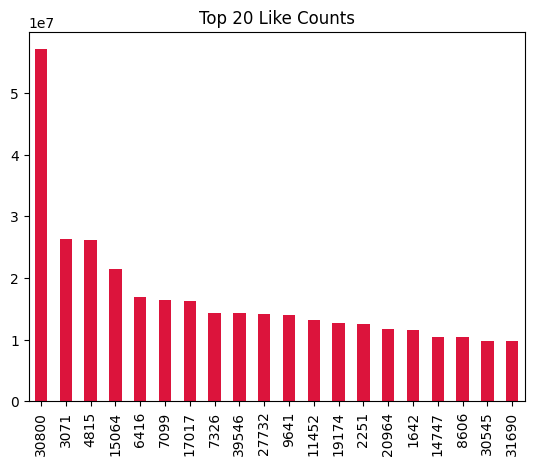

In [21]:
views.dropna().plot(kind='hist', bins=40, color='steelblue', edgecolor='white', title='Distribution of Views')

channel.value_counts().head(10).sort_values().plot(kind='barh', color='darkorange', title='Top 10 Channels by Video Count')

publish_date.dt.to_period('M').value_counts().sort_index().plot(kind='line', color='seagreen', title='Monthly Upload Count')

likes.dropna().sort_values(ascending=False).head(20).plot(kind='bar', color='crimson', title='Top 20 Like Counts')


## Quick Takeaway

A pandas Series can do a lot on its own: it supports inspection, filtering, transformation, arithmetic, and plotting.
If you stay within Series methods and use pandas-friendly cleaning steps first, your examples stay robust and easy to reuse.
